In [6]:
import pandas as pd

data1 = {
    'Name': ['Asha', 'Ravi', 'Kiran', 'Meena', 'John', 'Priya'],
    'Age': [20, 21, None, 22, 20, None],
    'Marks': [85, None, 78, 90, None, 88],
    'City': ['Hyderabad', 'Chennai', None, 'Mumbai', 'Delhi', 'Hyderabad']
}

df1 = pd.DataFrame(data1)

# Identify missing values.
print(df1.isnull())

# Count missing values column-wise.
print(df1.isnull().sum())

# Fill missing Age with mean.
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())
print(df1['Age'])

# Fill missing Marks with median.
df1['Marks'] = df1['Marks'].fillna(df1['Marks'].median())

# Fill missing City with mode.
df1['City'] = df1['City'].fillna(df1['City'].mode()[0])

# Drop rows where Marks are missing.
df1.dropna(subset=['Marks'], inplace=True)

# Compare dataset before and after cleaning.
print(df1)


    Name    Age  Marks   City
0  False  False  False  False
1  False  False   True  False
2  False   True  False   True
3  False  False  False  False
4  False  False   True  False
5  False   True  False  False
Name     0
Age      2
Marks    2
City     1
dtype: int64
0    20.00
1    21.00
2    20.75
3    22.00
4    20.00
5    20.75
Name: Age, dtype: float64
    Name    Age  Marks       City
0   Asha  20.00   85.0  Hyderabad
1   Ravi  21.00   86.5    Chennai
2  Kiran  20.75   78.0  Hyderabad
3  Meena  22.00   90.0     Mumbai
4   John  20.00   86.5      Delhi
5  Priya  20.75   88.0  Hyderabad


In [18]:
data2 = {
    'Emp_ID': [101,102,103,101,104,105,102],
    'Name': ['Ravi','Asha','John','Ravi','Kiran','Meena','Asha'],
    'Salary': [50000,60000,55000,50000,52000,58000,60000]
}
df2 = pd.DataFrame(data2)

# Find duplicate rows.
print(df2.duplicated())

# Remove duplicates. & Keep only first occurrence.
df2 = df2.drop_duplicates()
print(df2)

# Check number of rows before and after removal.
print(df2.shape)


0    False
1    False
2    False
3     True
4    False
5    False
6     True
dtype: bool
   Emp_ID   Name  Salary
0     101   Ravi   50000
1     102   Asha   60000
2     103   John   55000
4     104  Kiran   52000
5     105  Meena   58000
(5, 3)


In [21]:
data3 = {
    'Product': ['A','B','C','D'],
    'Price': ['100','200','150','300'],
    'Date': ['01-01-2024','02-01-2024','03-01-2024','04-01-2024']
}
df3 = pd.DataFrame(data3)

# Convert Price to numeric.
df3['Price'] = pd.to_numeric(df3['Price'])

# Convert Date to datetime.
df3['Date'] = pd.to_datetime(df3['Date'], dayfirst=True)

# Check data types before and after conversion.
print(df3.dtypes)


Product            object
Price               int64
Date       datetime64[ns]
dtype: object


In [23]:
sales = [100, 120, 130, 115, 5000, 140, 125, 110]
s = pd.Series(sales)

# Detect outlier using IQR method.
Q1 = s.quantile(0.25)
Q3 = s.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = s[(s < lower_bound) | (s > upper_bound)]
print(f"Outliers: {outliers.tolist()}")

# Remove outliers.
s = s[(s >= lower_bound) & (s <= upper_bound)]

# Compare mean before and after removal.
print(s)


Outliers: [5000]
0    100
1    120
2    130
3    115
5    140
6    125
7    110
dtype: int64


In [24]:
import numpy as np

marks = np.array([50, 60, 70, 80, 90])

# Perform Min-Max Normalization.
marks_min_max = (marks - np.min(marks)) / (np.max(marks) - np.min(marks))

# Perform Z-score Standardization.
marks_z_score = (marks - np.mean(marks)) / np.std(marks)

# Compare both methods.
print(f"Min-Max: {marks_min_max}")
print(f"Z-score: {marks_z_score}")

Min-Max: [0.   0.25 0.5  0.75 1.  ]
Z-score: [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]


In [ ]:
data6 = {
    'Email': [' test@gmail.com ', 'RAVI@GMAIL.COM', 'john123 @gmail.com', None]
}
df6 = pd.DataFrame(data6)

# Remove extra spaces.
df6['Email'] = df6['Email'].str.strip()

# Convert to lowercase.
df6['Email'] = df6['Email'].str.lower()

# Remove invalid spaces inside emails.
df6['Email'] = df6['Email'].str.replace(' ', '', regex=False)
# Create bins: Young (18-25), Adult (26-40), Senior (41+)
# Handle missing values.
df6['Email'] = df6['Email'].fillna('missing')

In [25]:
ages = [18, 22, 25, 30, 35, 40, 45, 50]

# Create bins: Young (18-25), Adult (26-40), Senior (41+)
# Assign category labels.
bins = [17, 25, 40, 100]
labels = ['Young', 'Adult', 'Senior']
age_series = pd.cut(ages, bins=bins, labels=labels)

# Count number of records in each bin.
print(age_series.value_counts())

Young     3
Adult     3
Senior    2
Name: count, dtype: int64


Correlation: 0.9974586998307349


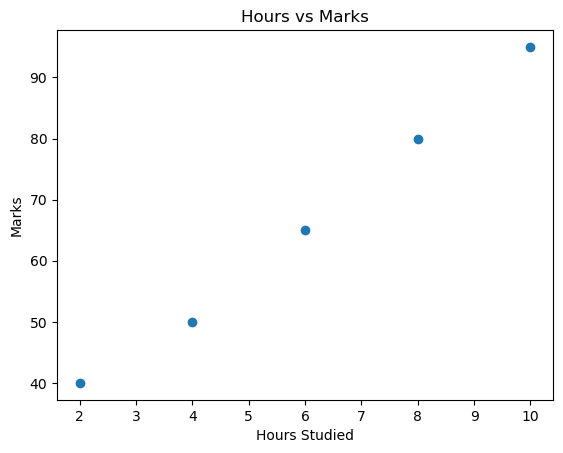

In [27]:
import matplotlib.pyplot as plt
data8 = {
    'Hours_Studied': [2,4,6,8,10],
    'Marks': [40,50,65,80,95]
}
df8 = pd.DataFrame(data8)
# Find correlation coefficient.
# Interpret result.
# Check if strong positive or negative correlation.
correlation = df8['Hours_Studied'].corr(df8['Marks'])
print(f"Correlation: {correlation}")

# Plot scatter diagram.
plt.scatter(df8['Hours_Studied'], df8['Marks'])
plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.title('Hours vs Marks')
plt.show()



In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
df9 = pd.read_csv('dataset.csv')


# Check for null values.
print(df9.isnull().sum())

# Replace missing income with median.
df9['Income'] = df9['Income'].fillna(df9['Income'].median())

# Remove duplicate customers.
df9 = df9.drop_duplicates()

# Detect outliers in Purchase_Amount.
Q1 = df9['Purchase_Amount'].quantile(0.25)
Q3 = df9['Purchase_Amount'].quantile(0.75)
IQR = Q3 - Q1
df9 = df9[~((df9['Purchase_Amount'] < (Q1 - 1.5 * IQR)) | (df9['Purchase_Amount'] > (Q3 + 1.5 * IQR)))]

# Standardize Income column.
scaler = StandardScaler()
df9['Income'] = scaler.fit_transform(df9[['Income']])

# Encode Gender column.
le = LabelEncoder()
df9['Gender'] = le.fit_transform(df9['Gender'])

# Find correlation between Income and Purchase_Amount.
correlation = df9['Income'].corr(df9['Purchase_Amount'])
print(f"Pearson Correlation (Income vs Purchase): {correlation:.4f}")

# Create bins for Age.
df9['Age_Group'] = pd.cut(df9['Age'], 
                          bins=[0, 25, 45, 65, 100], 
                          labels=['Gen Z/Student', 'Young Professional', 'Mid-Career', 'Retired'])

# Save cleaned dataset as CSV file.
df9.to_csv('cleaned_customer_data.csv', index=False)